CELL 1:IMPORT THƯ VIỆN

In [1]:
# Dữ liệu 
import pandas as pd
import numpy as np

# Ảnh & PyTorch 
import torch
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image

# Tìm kiếm tương đồng
import faiss
from sklearn.metrics.pairwise import cosine_similarity

# Vẽ biểu đồ 
import matplotlib.pyplot as plt
import seaborn as sns

# Tiện ích
import os
from tqdm import tqdm

pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 20)      
plt.rcParams['figure.figsize'] = (10, 5)    
sns.set_style('whitegrid')                  


print('Import thư viện thành công!')
print(f'PyTorch version : {torch.__version__}')
# Kiểm tra máy có GPU không. GPU giúp chạy nhanh hơn CPU rất nhiều.
# Laptop bình thường thường sẽ hiện 'cpu' – không sao, vẫn chạy được.
print(f'Device: {"cuda" if torch.cuda.is_available() else "cpu"}')

Import thư viện thành công!
PyTorch version : 2.11.0+cpu
Device: cpu


CELL 2: ĐƯỜNG DẪN DỮ LIỆU

In [2]:
DATA_DIR  = r'D:\New folder (3)\project\data\raw'  

CSV_PATH  = os.path.join(DATA_DIR, 'train.csv')
IMAGE_DIR = os.path.join(DATA_DIR, 'train_images')

# Thư mục lưu kết quả – tạo tự động nếu chưa có
PROCESSED = 'data/processed/'
RESULTS   = 'results/'
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(RESULTS,   exist_ok=True)

# Kiểm tra file có tồn tại không
for p in [CSV_PATH, IMAGE_DIR]:
    status = 'Đã tìm thấy thư mục' if os.path.exists(p) else 'Không tìm thấy – kiểm tra lại đường dẫn!'
    print(f'{status}  {p}')

Đã tìm thấy thư mục  D:\New folder (3)\project\data\raw\train.csv
Đã tìm thấy thư mục  D:\New folder (3)\project\data\raw\train_images


CELL 3: ĐỌC VÀ XEM THÔNG TIN CƠ BẢN DATASET

In [3]:
df = pd.read_csv(CSV_PATH)

print(f'Train: {df.shape[0]:,} dòng x {df.shape[1]:,} cột')

df.head()

Train: 34,250 dòng x 5 cột


,posting_id,image,image_phash,title,label_group
0,train_129225211,0000a68812bc7e98c42888dfb1c07da0.jpg,94974f937d4c2433,Paper Bag Victoria Secret,249114794
1,train_3386243561,00039780dfc94d01db8676fe789ecd05.jpg,af3f9460c2838f0f,"Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DO...",2937985045
2,train_2288590299,000a190fdd715a2a36faed16e2c65df7.jpg,b94cb00ed3e50f78,Maling TTS Canned Pork Luncheon Meat 397 gr,2395904891
3,train_2406599165,00117e4fc239b1b641ff08340b429633.jpg,8514fc58eafea283,Daster Batik Lengan pendek - Motif Acak / Camp...,4093212188
4,train_3369186413,00136d1cf4edede0203f32f05f660588.jpg,a6f319f924ad708c,Nescafe \xc3\x89clair Latte 220ml,3648931069


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34250 entries, 0 to 34249
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   posting_id   34250 non-null  str  
 1   image        34250 non-null  str  
 2   image_phash  34250 non-null  str  
 3   title        34250 non-null  str  
 4   label_group  34250 non-null  int64
dtypes: int64(1), str(4)
memory usage: 5.4 MB


In [5]:
df = pd.read_csv(CSV_PATH)
print("THÔNG TIN CƠ BẢN DATASET")
print(f"Tên bộ dữ liệu   : Shopee – Price Match Guarantee")
print(f"Số dòng (ảnh)    : {df.shape[0]:,}")
print(f"Số cột           : {df.shape[1]}")
print(f"Tên các cột      : {list(df.columns)}")
print("")
print("Thống kê label_group:")
label_counts = df['label_group'].value_counts()
print(f"  Tổng số nhóm           : {label_counts.shape[0]:,}")
print(f"  Số ảnh TB mỗi nhóm     : {label_counts.mean():.2f}")
print(f"  Nhóm ít ảnh nhất       : {label_counts.min()} ảnh")
print(f"  Nhóm nhiều ảnh nhất    : {label_counts.max()} ảnh")
print(f"  Nhóm có đúng 2 ảnh     : {(label_counts == 2).sum():,} nhóm")
print(f"  Loại bài toán          : Truy xuất, gợi ý hình ảnh tương đồng")

THÔNG TIN CƠ BẢN DATASET
Tên bộ dữ liệu   : Shopee – Price Match Guarantee
Số dòng (ảnh)    : 34,250
Số cột           : 5
Tên các cột      : ['posting_id', 'image', 'image_phash', 'title', 'label_group']

Thống kê label_group:
  Tổng số nhóm           : 11,014
  Số ảnh TB mỗi nhóm     : 3.11
  Nhóm ít ảnh nhất       : 2 ảnh
  Nhóm nhiều ảnh nhất    : 51 ảnh
  Nhóm có đúng 2 ảnh     : 6,979 nhóm
  Loại bài toán          : Truy xuất, gợi ý hình ảnh tương đồng


CELL 4: KIỂM TRA DỮ LIỆU THIẾU VÀ TRÙNG LẶP(LÀM SẠCH DỮ LIỆU)

In [6]:
# Kiểm tra ô trống (giá trị thiếu) trong từng cột
# isnull() trả về True/False cho từng ô, sum() đếm số ô bị thiếu
print('GIÁ TRỊ THIẾU (ô trống)')
print(df.isnull().sum())
print()

print('DÒNG TRÙNG LẶP')
print(f'Số dòng bị trùng: {df.duplicated().sum()}')
print()


GIÁ TRỊ THIẾU (ô trống)
posting_id     0
image          0
image_phash    0
title          0
label_group    0
dtype: int64

DÒNG TRÙNG LẶP
Số dòng bị trùng: 0



CELL 5: THỐNG KÊ LABEL_GROUP

In [7]:
so_anh_moi_nhom = df['label_group'].value_counts()

print('=== THỐNG KÊ LABEL_GROUP ===')
print(f'Tổng số nhóm sản phẩm   : {so_anh_moi_nhom.shape[0]:,}')
print(f'Ảnh ít nhất trong 1 nhóm: {so_anh_moi_nhom.min()} ảnh')
print(f'Ảnh nhiều nhất trong 1 nhóm: {so_anh_moi_nhom.max()} ảnh')
print(f'Trung bình số ảnh / nhóm: {so_anh_moi_nhom.mean():.2f} ảnh')
print(f'Nhóm có đúng 2 ảnh      : {(so_anh_moi_nhom == 2).sum():,} nhóm ({(so_anh_moi_nhom == 2).sum() / so_anh_moi_nhom.shape[0] * 100:.1f}%)')
print(f'Nhóm có trên 10 ảnh     : {(so_anh_moi_nhom > 10).sum():,} nhóm ({(so_anh_moi_nhom > 10).sum() / so_anh_moi_nhom.shape[0] * 100:.1f}%)')

=== THỐNG KÊ LABEL_GROUP ===
Tổng số nhóm sản phẩm   : 11,014
Ảnh ít nhất trong 1 nhóm: 2 ảnh
Ảnh nhiều nhất trong 1 nhóm: 51 ảnh
Trung bình số ảnh / nhóm: 3.11 ảnh
Nhóm có đúng 2 ảnh      : 6,979 nhóm (63.4%)
Nhóm có trên 10 ảnh     : 233 nhóm (2.1%)


CELL 6: BIỂU ĐỒ PHÂN BỐ DỮ LIỆU

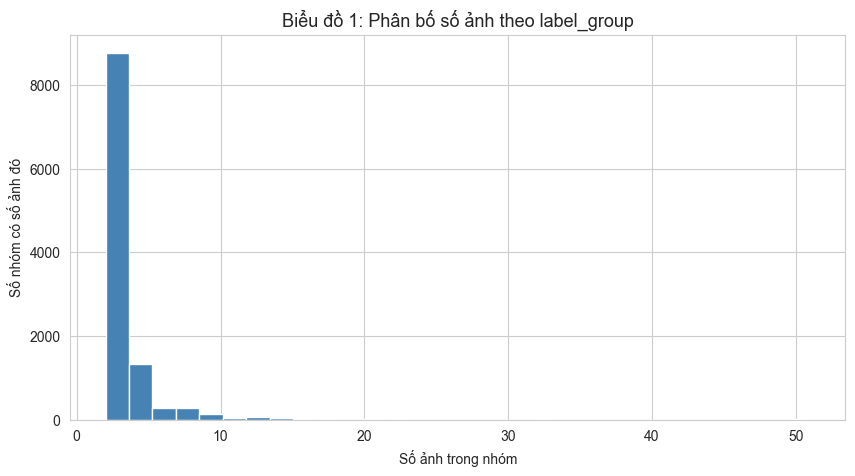

Nhận xét: Đa số nhóm chỉ có 2–3 ảnh, rất ít nhóm có trên 10 ảnh.
→ Dữ liệu mất cân bằng → ảnh hưởng đến Recall@K vì nhóm ít ảnh khó tìm đủ trong top-5.



In [8]:
# ── BIỂU ĐỒ 1: Histogram phân bố số ảnh theo label_group ──────────────
# Histogram giúp thấy toàn bộ 11,014 nhóm phân bố như thế nào
# Cột càng cao = có nhiều nhóm có số ảnh đó
plt.figure(figsize=(10, 5))
plt.hist(so_anh_moi_nhom.values, bins=30, color='steelblue', edgecolor='white')
plt.title('Biểu đồ 1: Phân bố số ảnh theo label_group', fontsize=13)
plt.xlabel('Số ảnh trong nhóm')
plt.ylabel('Số nhóm có số ảnh đó')
plt.savefig(f'{RESULTS}bieu_do_1_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Nhận xét: Đa số nhóm chỉ có 2–3 ảnh, rất ít nhóm có trên 10 ảnh.')
print('→ Dữ liệu mất cân bằng → ảnh hưởng đến Recall@K vì nhóm ít ảnh khó tìm đủ trong top-5.')
print()

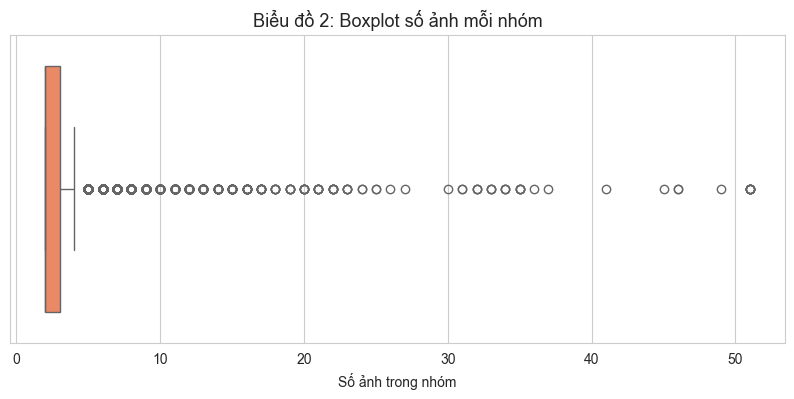

Nhận xét: Trung vị chỉ khoảng 2 ảnh/nhóm nhưng có nhiều outlier (nhóm có đến 51 ảnh).
→ Tỷ lệ nhóm nhiều nhất / ít nhất = 51 / 2 = 26x → mất cân bằng rõ rệt.



In [9]:
# ── BIỂU ĐỒ 2: Boxplot – mức độ mất cân bằng dữ liệu ─────────────────
# Boxplot cho thấy: trung vị, khoảng phân tán, và các outlier (điểm ngoại lệ)
plt.figure(figsize=(10, 4))
sns.boxplot(x=so_anh_moi_nhom.values, color='coral')
plt.title('Biểu đồ 2: Boxplot số ảnh mỗi nhóm', fontsize=13)
plt.xlabel('Số ảnh trong nhóm')
plt.savefig(f'{RESULTS}bieu_do_2_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Nhận xét: Trung vị chỉ khoảng {int(so_anh_moi_nhom.median())} ảnh/nhóm nhưng có nhiều outlier (nhóm có đến {so_anh_moi_nhom.max()} ảnh).')
print(f'→ Tỷ lệ nhóm nhiều nhất / ít nhất = {so_anh_moi_nhom.max()} / {so_anh_moi_nhom.min()} = {so_anh_moi_nhom.max() / so_anh_moi_nhom.min():.0f}x → mất cân bằng rõ rệt.')
print()

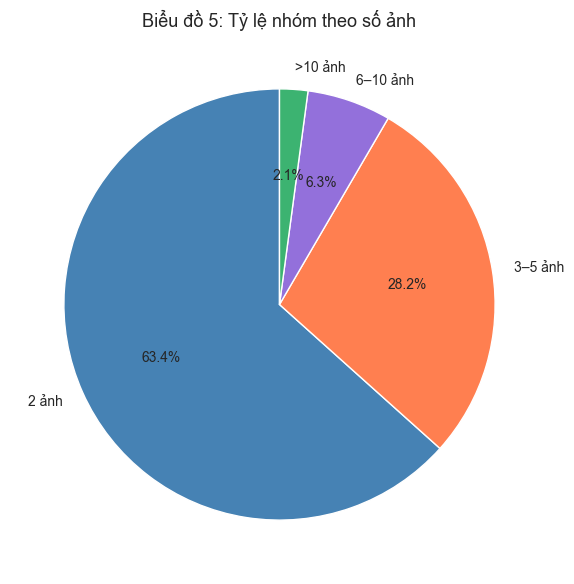

Nhận xét: 63.4% số nhóm chỉ có đúng 2 ảnh.
→ Đây là thách thức lớn cho Recall@K vì hệ thống chỉ tìm được tối đa 1 ảnh đúng trong top-5 cho các nhóm này.


In [10]:
# ── BIỂU ĐỒ 5: Pie chart – tỷ lệ nhóm theo số ảnh ────────────────────
# Pie chart cho thấy % từng loại nhóm ngay lập tức, dễ đọc nhất

# Phân loại các nhóm theo số ảnh
# bins=[1,2,5,10,999] tức là:
#   (1,2] = đúng 2 ảnh
#   (2,5] = 3 đến 5 ảnh
#   (5,10] = 6 đến 10 ảnh
#   (10,999] = hơn 10 ảnh
phan_loai = pd.cut(
    so_anh_moi_nhom,
    bins=[1, 2, 5, 10, 999],
    labels=['2 ảnh', '3–5 ảnh', '6–10 ảnh', '>10 ảnh']
)
ty_le = phan_loai.value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    ty_le.values,
    labels=ty_le.index,
    autopct='%1.1f%%',   # hiển thị % trên từng miếng
    colors=['steelblue', 'coral', 'mediumpurple', 'mediumseagreen'],
    startangle=90
)
plt.title('Biểu đồ 5: Tỷ lệ nhóm theo số ảnh', fontsize=13)
plt.savefig(f'{RESULTS}bieu_do_5_piechart.png', dpi=150, bbox_inches='tight')
plt.show()

nhom_2_anh = ty_le.get('2 ảnh', 0)
phan_tram_2_anh = nhom_2_anh / so_anh_moi_nhom.shape[0] * 100
print(f'Nhận xét: {phan_tram_2_anh:.1f}% số nhóm chỉ có đúng 2 ảnh.')
print('→ Đây là thách thức lớn cho Recall@K vì hệ thống chỉ tìm được tối đa 1 ảnh đúng trong top-5 cho các nhóm này.')

CELL 7: CHỌN TẬP CON DỮ LIỆU

In [11]:
so_anh_moi_nhom = df['label_group'].value_counts()

# Bước 1: Chỉ giữ nhóm có từ 2 ảnh trở lên
nhom_hop_le = so_anh_moi_nhom[so_anh_moi_nhom >= 2].index
df_loc = df[df['label_group'].isin(nhom_hop_le)].copy()

# Bước 2: Lấy tối đa 3 ảnh mỗi nhóm
# Dùng vòng lặp thay vì groupby().apply() để tránh lỗi pandas 2.0+
danh_sach = []
for nhom, du_lieu_nhom in df_loc.groupby('label_group'):
    danh_sach.append(du_lieu_nhom.sample(min(len(du_lieu_nhom), 3), random_state=42))

df_subset = pd.concat(danh_sach, ignore_index=True)

# Bước 3: Giới hạn tổng số ảnh
SUBSET_SIZE = 5000
df_subset = df_subset.sample(
    min(SUBSET_SIZE, len(df_subset)),
    random_state=42
).reset_index(drop=True)

print(f'Tập con: {len(df_subset)} ảnh, {df_subset["label_group"].nunique()} nhóm')
print(f'Các cột: {list(df_subset.columns)}')
df_subset.to_csv(f'{PROCESSED}subset.csv', index=False)
print('Đã lưu vào data/processed/subset.csv')

Tập con: 5000 ảnh, 4322 nhóm
Các cột: ['posting_id', 'image', 'image_phash', 'title', 'label_group']
Đã lưu vào data/processed/subset.csv


CELL 8: TIỀN XỬ LÝ ẢNH VÀ TORCHVISION.TRANSFORM

CELL 9: LOAD RESNET50 VÀ TRÍCH XUẤT VECTOR ĐẶC TRƯNG

CELL 10: TÍNH COSINE SIMILARITY VÀ LẤY TOP5 KẾT QUẢ

CELL 11: TÍNH PRECISION@K VÀ RECALL@K

CELL 12: TRỰC QUAN HÓA KẾT QUẢ: ẢNH QUERY + TOP5

CELL 13: NHẬN XÉT KẾT QUẢ BASELINE